# **Part 1: Regression**
- simple linear regression

In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#load dataset
df = pd.read_csv('automobile_dataset_cleaned.csv')
print(df.head())
print(df.shape)

            Make   Model  Year Fuel_Type Transmission  Engine_Size  Mileage  \
0  Mercedes-Benz     GLE  2024    Petrol    Automatic          2.3      100   
1        Hyundai  Tucson  2008    Petrol    Automatic          2.3   387035   
2     Volkswagen    Golf  2021    Hybrid    Automatic          1.9    46054   
3      Chevrolet   Tahoe  2005    Petrol    Automatic          2.2   141302   
4         Toyota   Camry  2022    Petrol    Automatic          1.9    32813   

   Horsepower  Torque  Owners  ...  Location_FL Location_GA Location_IL  \
0       186.0   196.0       1  ...          0.0         0.0         1.0   
1       189.0   190.0       4  ...          1.0         0.0         0.0   
2       158.0   153.0       1  ...          0.0         0.0         0.0   
3       169.0   165.0       5  ...          1.0         0.0         0.0   
4       149.0   141.0       1  ...          0.0         0.0         0.0   

  Location_MI Location_NC  Location_NY Location_OH  Location_PA  Location_

In [2]:
#set variables
X = df[['Year']]
y = df['Selling_Price']

#split 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training:", X_train.shape[0])
print("Testing:", X_test.shape[0])


Training: 4400
Testing: 1100


In [3]:
#use sklearn to calculate slope and intercept
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Slope (a):", model_simple.coef_[0])
print("Intercept (b):", model_simple.intercept_)

Slope (a): 1759.1324245341345
Intercept (b): -3531438.33577354


In [4]:
#manual calculation
x = X_train['Year'].values 
y_vals = y_train.values

x_mean = x.mean()
y_mean = y_vals.mean()

#slope
numerator = np.sum((x - x_mean) * (y_vals - y_mean))
denominator = np.sum((x - x_mean) ** 2)
a_manual = numerator / denominator

#intercept
b_manual = y_mean - a_manual * x_mean

print("manual slope (a):", a_manual)
print("manual intercept (b):", b_manual)
print()
print("sklearn slope:", model_simple.coef_[0])
print("sklearn intercept:", model_simple.intercept_)

manual slope (a): 1759.1324245341311
manual intercept (b): -3531438.3357735337

sklearn slope: 1759.1324245341345
sklearn intercept: -3531438.33577354


In [5]:
#predict on test set
y_pred = model_simple.predict(X_test)

#calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE (Mean Absolute Error):", mae)
print("RMSE (Root Mean Squared Error):", rmse)
print("R² Score:", r2)

MAE (Mean Absolute Error): 5624.929561940992
RMSE (Root Mean Squared Error): 7491.994369024739
R² Score: 0.6434580099950234


- multiple linear regression

In [6]:
#get one-hot encoded columns for Make and Body_Type
make_cols = [col for col in df.columns if col.startswith('Make_')]
body_cols = [col for col in df.columns if col.startswith('Body_Type_')]

#set features
features = ['Year', 'Engine_Size', 'Mileage', 'Horsepower', 'Torque',
                      'Owners', 'Accident_History', 'Fuel_Efficiency'] + make_cols + body_cols

X_multi = df[features]
y_multi = df['Selling_Price']

#split 80% train and 20% test
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print("Total features:", X_multi.shape[1])
print("Training samples:", X_train_multi.shape[0])
print("Testing samples:", X_test_multi.shape[0])

Total features: 23
Training samples: 4400
Testing samples: 1100


In [7]:
#calculate and train the model
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

#show coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_multi.coef_
})
print(coefficients)
print("\nIntercept:", model_multi.intercept_)

                Feature  Coefficient
0                  Year  1411.574348
1           Engine_Size  -273.376252
2               Mileage    -0.022429
3            Horsepower    -4.371183
4                Torque     5.678513
5                Owners    20.304082
6      Accident_History -2059.425942
7       Fuel_Efficiency     0.415828
8             Make_Audi  6604.123030
9              Make_BMW  6960.921800
10       Make_Chevrolet -1665.919040
11            Make_Ford -3386.259603
12           Make_Honda -3287.735552
13         Make_Hyundai -3643.057398
14   Make_Mercedes-Benz  7707.297130
15          Make_Nissan -3725.806514
16          Make_Toyota -3201.587670
17      Make_Volkswagen -2361.976183
18      Body_Type_Coupe   434.900505
19  Body_Type_Hatchback -3088.910056
20        Body_Type_SUV  1690.145809
21      Body_Type_Sedan -1288.501950
22      Body_Type_Truck  2252.365693

Intercept: -2827856.3858185452


In [8]:
#predict on test set
y_pred_multi = model_multi.predict(X_test_multi)

#calculate metrics
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("MAE (Mean Absolute Error):", mae_multi)
print("RMSE (Root Mean Squared Error):", rmse_multi)
print("R² Score:", r2_multi)

MAE (Mean Absolute Error): 4064.930626483924
RMSE (Root Mean Squared Error): 5483.989533194084
R² Score: 0.8089667193406107


- selling price prediction

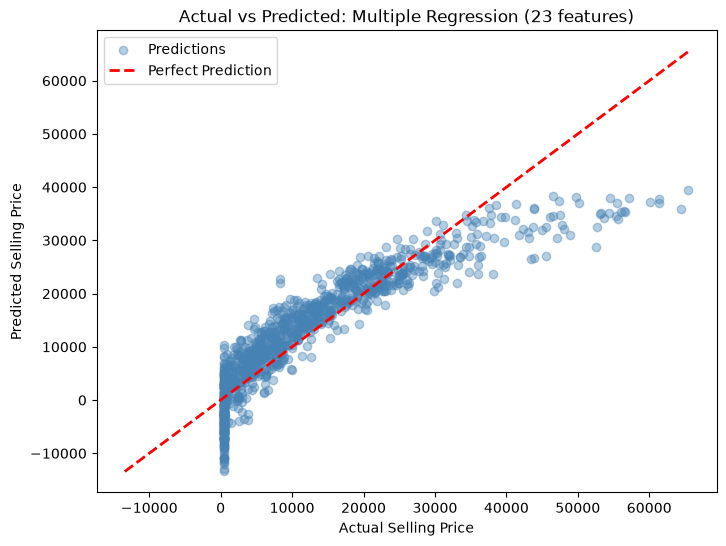

In [9]:
plt.figure(figsize=(8, 6))

# Scatter plot: actual vs predicted
plt.scatter(y_test_multi, y_pred_multi, alpha=0.4, color='steelblue', label='Predictions')

# Perfect prediction reference line
min_val = min(y_test_multi.min(), y_pred_multi.min())
max_val = max(y_test_multi.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted: Multiple Regression (23 features)')
plt.legend()
plt.show()

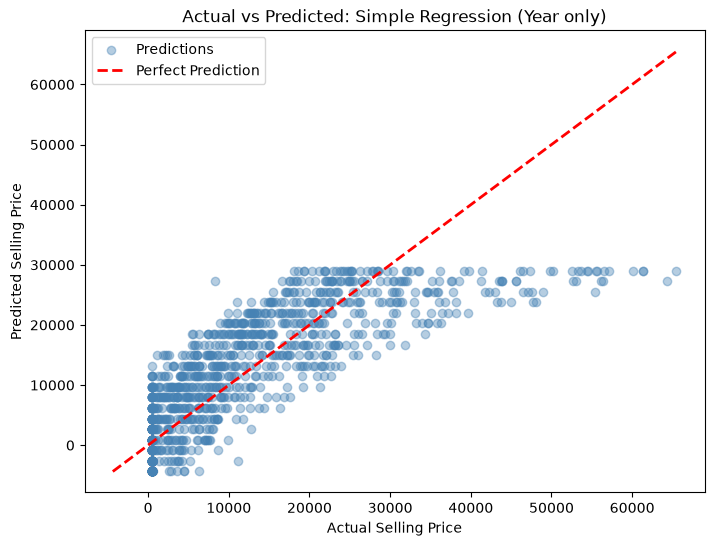

In [10]:
plt.figure(figsize=(8, 6))

# Scatter plot: actual vs predicted (Simple Regression)
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', label='Predictions')

# Perfect prediction reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted: Simple Regression (Year only)')
plt.legend()
plt.show()

# **Part 2: Classification**

- preparing classification data

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

In [12]:
#data cleaning
print(df[['Engine_Size', 'Fuel_Efficiency', 'Fuel_Type']].isnull().sum())

#no missing values. this part was completed in LAB 2 (Part 3: Data Cleaning)

Engine_Size        0
Fuel_Efficiency    0
Fuel_Type          0
dtype: int64


In [13]:
#label encoding (Electric = 1, others = 0)

df = df[df['Fuel_Type'] != 'Hybrid'].copy()

df['Fuel_target'] = (df['Fuel_Type'] == 'Electric').astype(int)
print("\nClass distribution:")
print(df['Fuel_target'].value_counts())


Class distribution:
Fuel_target
0    4818
1     145
Name: count, dtype: int64


In [14]:
#feature scaling
#select features
features2 = ['Engine_Size', 'Fuel_Efficiency']

X2 = df[features2]
y2 = df['Fuel_target']

scaler2 = StandardScaler()
X2_scaled = pd.DataFrame(scaler2.fit_transform(X2), columns=features2)

print(X2_scaled.describe().loc[['mean', 'std']])

       Engine_Size  Fuel_Efficiency
mean  1.567689e-16     1.975718e-16
std   1.000101e+00     1.000101e+00


In [15]:
#train/test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Training samples:", X_train2.shape[0])
print("Testing samples:", X_test2.shape[0])

Training samples: 3970
Testing samples: 993


In [16]:
#balanced dataset
#check current class balance
print("Before balancing:")
print(y_train2.value_counts())

train2 = X_train2.copy()
train2['target'] = y_train2.values

majority2 = train2[train2['target'] == 0]
minority2 = train2[train2['target'] == 1]
minority2_up = resample(minority2, replace=True, n_samples=len(majority2), random_state=42)
train2_bal = pd.concat([majority2, minority2_up])

X_train2_bal = train2_bal.drop(columns='target')
y_train2_bal = train2_bal['target']

print("After balancing:")
print(y_train2_bal.value_counts())

Before balancing:
Fuel_target
0    3854
1     116
Name: count, dtype: int64
After balancing:
target
0    3854
1    3854
Name: count, dtype: int64


- logic regression

In [17]:
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2_bal, y_train2_bal)

y_pred2 = model2.predict(X_test2)

print("Coefficients :", model2.coef_)
print("Intercept :", model2.intercept_)

Coefficients : [[-2.41934319  1.80858284]]
Intercept : [-5.00643212]


- decision boundary visualization

c:\Users\l380\Desktop\This Folder\code\git\ML-CPE\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


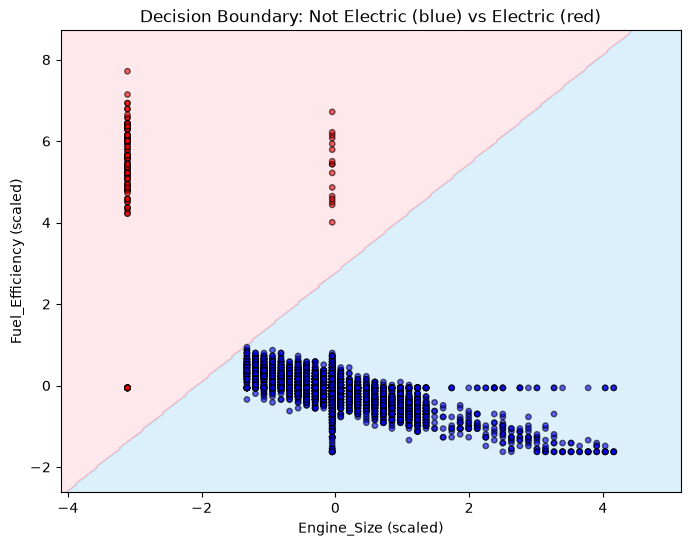

In [18]:
# Create a mesh grid covering the feature space
x_min, x_max = X2_scaled['Engine_Size'].min() - 1, X2_scaled['Engine_Size'].max() + 1
y_min, y_max = X2_scaled['Fuel_Efficiency'].min() - 1, X2_scaled['Fuel_Efficiency'].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict class for every point on the grid
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary + actual data points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#89CFF0', '#FFB6C1']))
plt.scatter(X2_scaled['Engine_Size'], X2_scaled['Fuel_Efficiency'], c=y2,
            cmap=ListedColormap(['blue', 'red']), edgecolor='k', alpha=0.6, s=15)

plt.xlabel('Engine_Size (scaled)')
plt.ylabel('Fuel_Efficiency (scaled)')
plt.title('Decision Boundary: Not Electric (blue) vs Electric (red)')
plt.show()

- confusion matrix

In [19]:
print("Accuracy:", accuracy_score(y_test2, y_pred2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))

print("\nClassification Report:")
print(classification_report(y_test2, y_pred2, target_names=['Not Electric', 'Electric']))

Accuracy: 1.0

Confusion Matrix:
[[964   0]
 [  0  29]]

Classification Report:
              precision    recall  f1-score   support

Not Electric       1.00      1.00      1.00       964
    Electric       1.00      1.00      1.00        29

    accuracy                           1.00       993
   macro avg       1.00      1.00      1.00       993
weighted avg       1.00      1.00      1.00       993



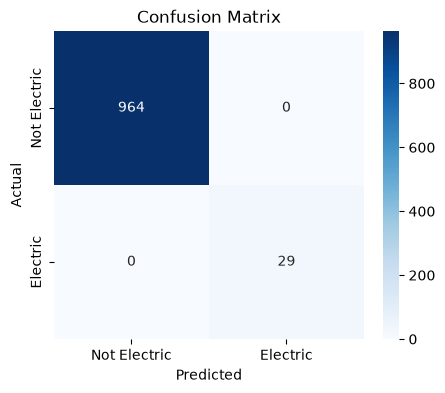

In [20]:
import seaborn as sns

cm = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Electric', 'Electric'],
            yticklabels=['Not Electric', 'Electric'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()